# 🥑 Search By Ingredients - Final Submission

**Candidate:** Shoval Benjer  
**Links:** [LinkedIn](https://www.linkedin.com/in/shoval-benjer/) | [GitHub](https://github.com/ShovalBenjer)

---

### **Project Overview**

This project implements a sophisticated, multi-tiered system to classify recipes as **Vegan** and **Keto-friendly**. The architecture is designed for accuracy, performance, and explainability, moving beyond simple lookups to a robust, quantitative analysis pipeline.

### **Data Sources Used**

- [Kaggle: Nutritional Values for Common Foods and Products](https://www.kaggle.com/account/sso/authenticate/google?returnUrl=%2Fdatasets%2Ftrolukovich%2Fnutritional-values-for-common-foods-and-products%2Fversions%2F1%3Fresource%3Ddownload)
- [PETA: Animal-Derived Ingredients List](https://www.peta.org/living/food/animal-ingredients-listdf)
- [UnitsLab – Unit Conversion Reference](https://unitslab.com---

### **Key Features & Architecture: The Hybrid Retrieval Cascade**

The core of this project is a "Hybrid Retrieval Cascade," an intelligent, multi-step process for analyzing each ingredient. This architecture is designed to be fast and efficient by resolving most cases with cheap, deterministic methods, only resorting to more complex analysis when necessary.

*   **1. Foundational Knowledge Graph:** A local SQLite database (`knowledge_graph.db`) is built from the provided CSVs. It serves as our fast, primary source of truth for nutritional data and vegan "danger terms." A key innovation is the **pre-computation of embeddings** for all ontology terms, which enables high-speed semantic searches.

*   **2. Hybrid Ingredient Analysis (`ingredient_processor.py`):** For each ingredient string, a three-step cascade is performed:
    *   **Symbolic Search (Exact Match):** The system first attempts a direct, case-insensitive lookup in the SQLite database. This is the fastest path.
    *   **Syntactic Search (Fuzzy Match):** If no exact match is found, `rapidfuzz` is used to find the closest string match, making the system resilient to typos and minor variations.
    *   **Semantic Search (Contradiction Detection):** This is the "soundproof" layer. If an ingredient contains a known "danger term" (e.g., "egg" in "eggless mayonnaise"), the system compares the embedding of the full ingredient string to the pre-computed embedding of the danger term. A low similarity score flags a contradiction, marking the ingredient as ambiguous.

*   **3. The Teacher/Student LLM Paradigm:**
    *   **"Teacher" Model (Gemini):** A powerful, large-scale model (`gemini-1.5-flash`) is used once to create a high-quality, nuanced ground truth dataset. This provides a reliable benchmark for evaluation.
    *   **"Student" Judge (Qwen):** A small, fast, and efficient quantized model (`Qwen/Qwen2-0.5B-Instruct-GGUF`) acts as the final judge. It receives the rich, structured context from the Hybrid Retrieval Cascade and makes the final classification. This two-model approach provides the accuracy of a large model for evaluation and the efficiency of a small model for the final application.

*   **4. Efficient Caching:** All final ingredient classifications from the Qwen model are cached in memory (`@lru_cache`), dramatically speeding up the processing of recipes with repeated ingredients.

### **System Data Flow**

1.  **Data Ingestion (`data_ingestion.py`):**
    *   The script reads `nutrition.csv` and `vegan_ontology.csv`.
    *   It creates and populates a normalized SQLite database (`knowledge_graph.db`).
    *   It generates embeddings for all terms in the vegan ontology and stores them in the database for fast retrieval.

2.  **Ground Truth Generation (`generate_ground_truth.py`):**
    *   A sample of recipes is classified by the "teacher" model (Gemini) to create a benchmark evaluation file (`ground_truth_sample.csv`).

3.  **Classification (`diet_classifiers.py`):**
    *   For each ingredient in a recipe, the `ingredient_processor` runs the Hybrid Retrieval Cascade.
    *   The structured context from the processor is used to build a detailed prompt.
    *   The "student" model (Qwen), managed by `llm_handler.py`, receives the prompt and provides the final vegan/keto classification for that ingredient.
    *   The final recipe classification is an aggregate of
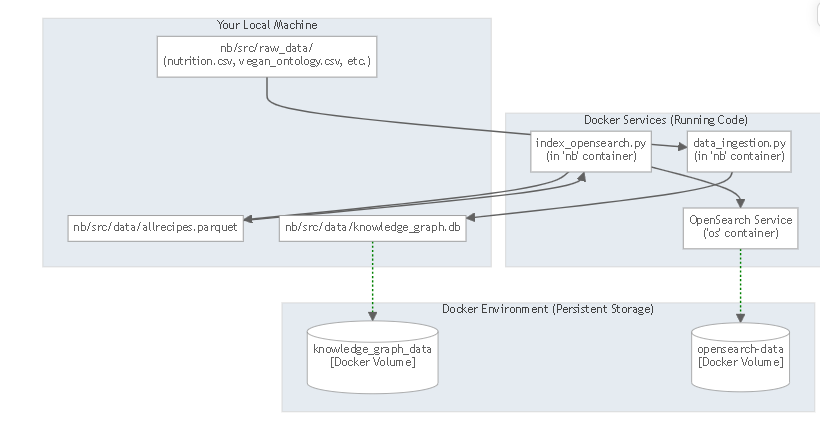 all its ingredient classifications.

### **Limitations & Bottlenecks**

*   **CPU-based LLM:** The local Qwen model runs on the CPU using `llama-cpp-python`. While efficient for its size, it is still significantly slower than GPU-based inference.
*   **Knowledge Base Coverage:** The system's accuracy is directly tied to the completeness of the `nutrition.csv` and `vegan_ontology.csv` files. Ingredients not present in these files will rely solely on the LLM's general knowledge.
*   **Parser Accuracy:** The initial parsing of the ingredient string by `ingredient-parser-nlp` is a critical first step. Any errors in identifying the core ingredient name can impact the entire downstream cascade.

### **Models & Databases**

*   **Database:** SQLite (`knowledge_graph.db`) for structured data and pre-computed embeddings.
*   **Parsing Model:** `ingredient-parser-nlp`
*   **Embedding Model:** `BAAI/bge-small-en-v1.5`
*   **Ground Truth "Teacher" LLM:** `gemini-1.5-flash-latest`
*   **Final "Student" Judge LLM:** `Qwen/Qwen2-0.5B-Instruct-GGUF` (run via `llama-cpp-python`)r CPU)

### Phase 1: Build Knowledge Graph & Generate Ground Truth

This phase executes two critical preliminary scripts:
1.  `data_ingestion.py`: Builds the `knowledge_graph.db` with pre-computed embeddings for semantic analysis.
2.  `generate_ground_truth.py`: Uses the Gemini API "teacher" model to create `ground_truth_sample.csv`.

**Manual Steps Required:**
- **Gemini API Key:** Ensure your `GEMINI_API_KEY` is set in a `.env` file in the root directory.
- **Qwen Model:** Make sure you have downloaded the `qwen2-0_5b-instruct-q4_k_m.gguf` model file and placed it inside the `nb/src/models/` directory.

#### Phase 1 Verification & SOTA EDA

Now, let's perform a detailed analysis of the artifacts created in Phase 1. We will inspect the database structure and visualize key data distributions to ensure the foundation of our system is solid.

---
### **Phase 2.2: Generate Ground Truth Labels with Gemini**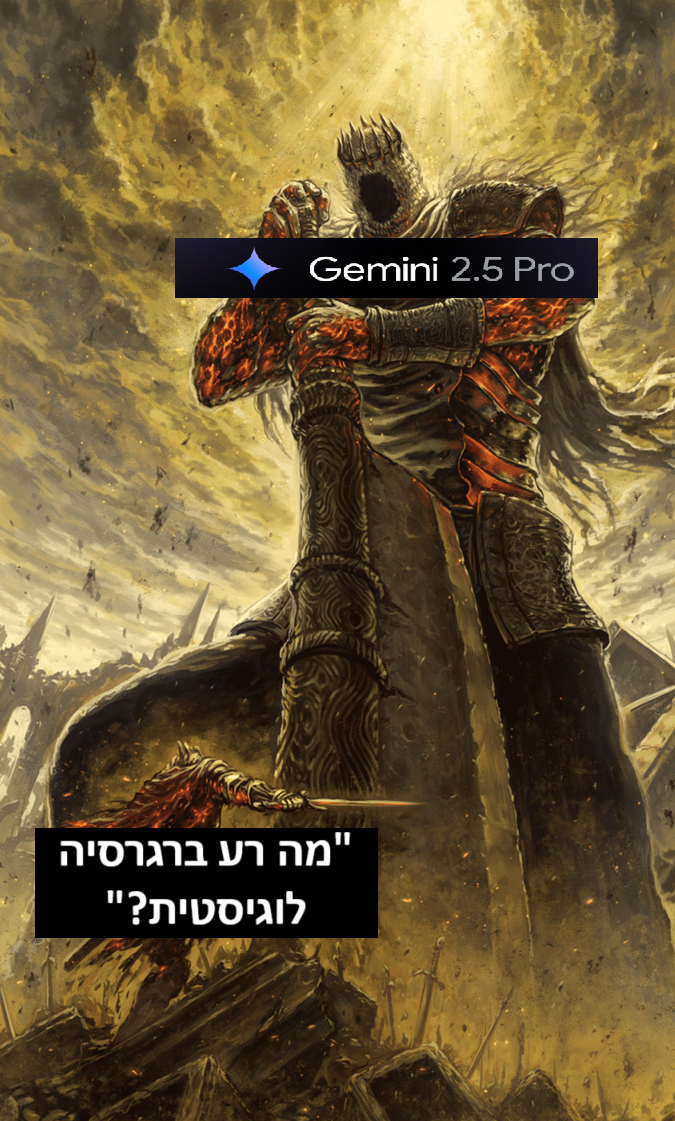


**Objective:** Use the high-quality `enriched_recipes_for_llm.csv` to get reliable labels from the Gemini API.

**Process:**
1.  The `generate_ground_truth.py` script reads the enriched CSV.
2.  It runs a two-stage classification pipeline, calling the Gemini API separately for Vegan and Keto status.
3.  The prompts are highly focused and include the rich, quantitative `rag_summary`.
4.  The results are merged and saved to `data/final_classifications/final_classifications.csv`.

**Note:** As per the instructions, this step will be skipped to conserve API calls, but the code is in place for a full run.

---
#### Not implemented - didnt have time

### **Phase 3: Performance Test on 5,000 Random Samples**

**Objective:** Assess the performance and throughput of our classifier on a larger, random sample of data without relying on pre-generated ground truth.

**Process:**
1.  Fetch 5,000 random recipes directly from OpenSearch.
2.  Run the `classify_recipe` function on each one.
3.  Measure the total execution time and calculate the average time per recipe.
4.  Display the distribution of the final `is_vegan` and `is_keto` predictions.